In [28]:
#Creek at P5

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [30]:
pip install hampel

Note: you may need to restart the kernel to use updated packages.


In [31]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [32]:
C1hobodf = pd.read_csv("Dwnstrm_current.csv")
C1mandf = pd.read_csv("Well_Sampling_Data_ALL - C1.csv")
C1hobodf["Date-Time"] = pd.to_datetime(C1hobodf["Date-Time"])
C1mandf["Date"] = pd.to_datetime(C1mandf["Date"])

In [33]:
C1mandf

,Date,Temp (C),SPC,Cond,TDS (ppt)
0,2024-07-08,19.9,637.0,577.0,0.3
1,2024-07-10,18.0,633.0,549.0,0.3
2,2024-07-16,19.7,660.0,593.0,0.3
3,2024-07-19,18.6,678.0,595.0,0.3
4,2024-07-23,18.4,658.0,577.0,0.3
5,2024-07-26,19.7,666.0,599.0,0.3
6,2024-07-28,20.2,689.0,626.0,0.3
7,2024-07-30,20.1,693.0,628.0,0.3
8,2024-08-02,21.5,552.0,516.0,0.3
9,2024-08-03,21.3,592.0,550.0,0.3


In [34]:
print(C1hobodf["Specific Conductivity"])

0          0.000000
1        739.583984
2        748.230957
3        745.843811
4        747.708008
            ...    
51474    572.774048
51475    572.850098
51476    574.455383
51477    575.493347
51478    575.974365
Name: Specific Conductivity, Length: 51479, dtype: float64


In [35]:
#filtering the data to remove the spikes, which are the result of removing the hobo from the well during manual measurements
C1filteredhobo = hampel(C1hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)

print(C1filteredhobo.filtered_data)

0          0.000000
1        739.583984
2        748.230957
3        745.843811
4        747.708008
            ...    
51474    572.774048
51475    572.850098
51476    574.455383
51477    575.493347
51478    575.974365
Length: 51479, dtype: float32


In [36]:
C1filteredhoboseries = pd.Series(C1filteredhobo.filtered_data, index = C1hobodf.index)
C1filteredhobo = C1filteredhoboseries[1:]              #I used the google AI overview for this line of code :/

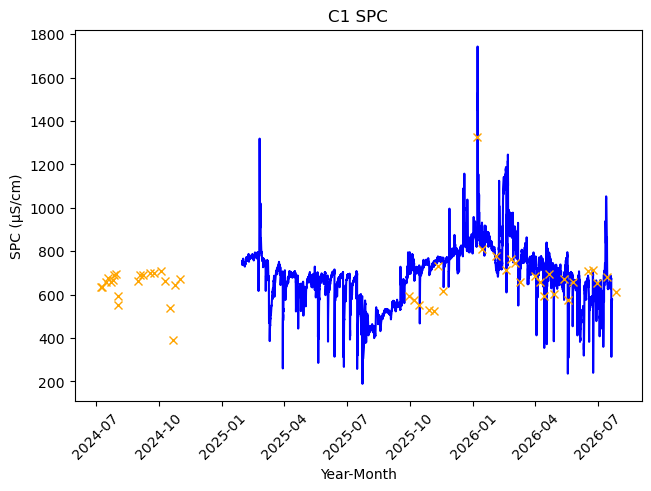

In [37]:
C1hobodate = C1hobodf["Date-Time"]
C1slicedhobodate = C1hobodate[1:]

fig, ax = plt.subplots(layout='constrained')
ax.plot(C1slicedhobodate, C1filteredhobo, color="blue", label = "HOBO continuous temperature")
ax.plot(C1mandf.Date, C1mandf.loc[:,"SPC"], 'x', color = "orange", label = "manual SPC")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.title("C1 SPC")
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-02")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
#fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [38]:
#Creek at P5

In [39]:
C5hobodf = pd.read_csv("P5_creek_cond_current.csv")
C5mandf = pd.read_csv("Well_Sampling_Data_ALL - C5.csv")
C5hobodf["Date-Time"] = pd.to_datetime(C5hobodf["Date-Time"])
C5mandf["Date"] = pd.to_datetime(C5mandf["Date"])

In [40]:
C5mandf

,Date,Temp (C),SPC,Cond,TDS (ppt),Temp upstream of culvert (C),SPC upstream of culvert,Cond upstream of culvert,TDS upstream of culvert (ppt),Temp in culvert (C),SPC in culvert,Cond in culvert,TDS in culvert (ppt)
0,2024-06-25,21.3,564.0,607.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-06-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-06-29,19.2,341.8,303.8,0.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-07-06,20.8,562.0,517.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-07-08,21.1,623.0,576.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2024-07-10,20.0,654.0,592.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2024-07-16,20.7,674.0,619.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2024-07-19,19.9,685.0,619.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2024-07-23,19.8,671.0,604.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2024-07-26,21.0,682.0,630.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
print(C5hobodf["Specific Conductivity"])

0        726.904785
1        727.360596
2        727.164917
3        727.011719
4        727.247009
            ...    
64469    524.592224
64470    524.313110
64471    524.139404
64472    522.786682
64473    522.832947
Name: Specific Conductivity, Length: 64474, dtype: float64


In [42]:
#filtering the data to remove the spikes, which are the result of removing the hobo from the well during manual measurements
C5filteredhobo = hampel(C5hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)

print(C5filteredhobo.filtered_data)

0        726.904785
1        727.360596
2        727.164917
3        727.247009
4        727.247009
            ...    
64469    524.592224
64470    524.313110
64471    524.139404
64472    522.786682
64473    522.832947
Length: 64474, dtype: float32


In [43]:
C5filteredhoboseries = pd.Series(C5filteredhobo.filtered_data, index = C5hobodf.index)
C5filteredhobo = C5filteredhoboseries[1:]              #I used the google AI overview for this line of code :/

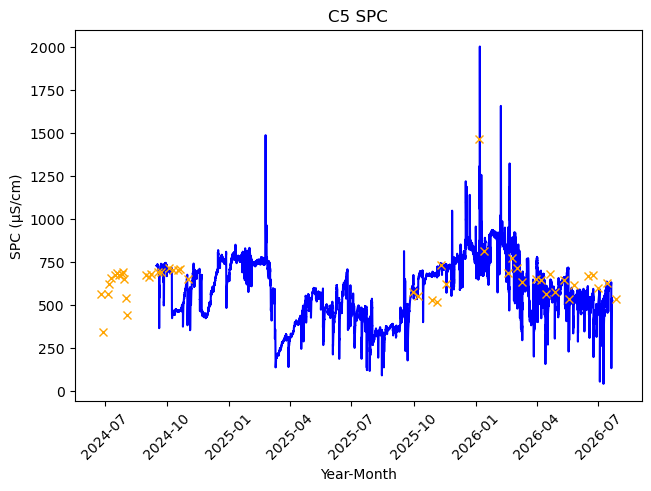

In [44]:
C5hobodate = C5hobodf["Date-Time"]
C5slicedhobodate = C5hobodate[1:]

fig, ax = plt.subplots(layout='constrained')
ax.plot(C5slicedhobodate, C5filteredhobo, color="blue", label = "HOBO continuous temperature")
ax.plot(C5mandf.Date, C5mandf.loc[:,"SPC"], 'x', color = "orange", label = "manual SPC")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.title("C5 SPC")
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-02")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
#fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [45]:
precip = pd.read_csv("NOAAFaribaultPrecipitation.csv")
precip["Date"] = pd.to_datetime(precip["Date"])
precip = precip[precip["PrecipitationCM"] != 0]
precip

,Date,PrecipitationIN,PrecipitationCM
0,2024-07-23,0.29,0.7366
1,2024-07-24,0.02,0.0508
7,2024-07-30,0.02,0.0508
9,2024-08-01,2.60,6.6040
10,2024-08-02,0.10,0.2540
...,...,...,...
710,2026-07-03,0.24,0.6096
712,2026-07-05,0.10,0.2540
714,2026-07-07,0.54,1.3716
727,2026-07-20,1.45,3.6830


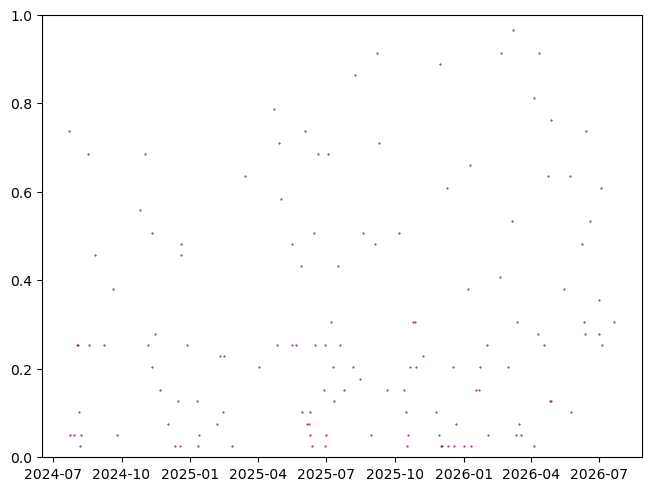

In [46]:
fig, ax  = plt.subplots(layout='constrained')
ax.scatter(precip.Date, precip.PrecipitationCM, color="purple", s = 0.2, label = "precipitation")
plt.ylim(0, 1)

plt.show();

TypeError: can only concatenate list (not "PathCollection") to list

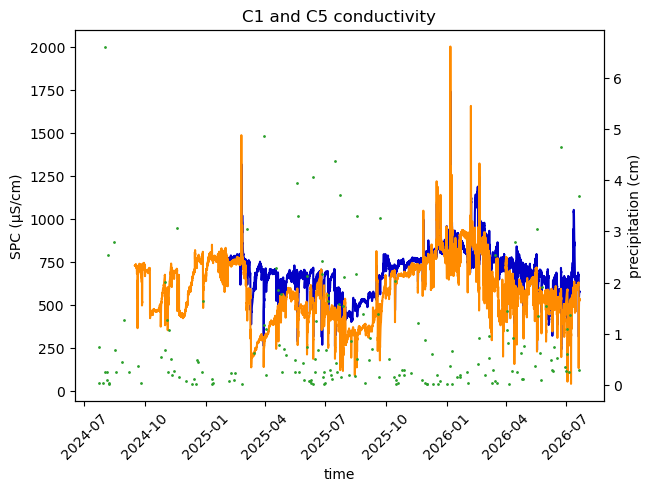

In [47]:
fig, ax1 = plt.subplots(layout='constrained')
ax1.set_xlabel('time')
ax1.set_ylabel('SPC (µS/cm)')
C1 = ax1.plot(C1slicedhobodate, C1filteredhobo, color="#0200C6", label = "C1 daily average SPC")
C5 = ax1.plot(C5slicedhobodate, C5filteredhobo, color="#FF8B00", label = "C5 daily average SPC")
ax1.tick_params(axis='x', rotation=45)


ax2 = ax1.twinx() 
ax2.set_ylabel('precipitation (cm)') 
# ax2.scatter(precip.Date, precip.PrecipitationCM, s = 0.2, color = "purple")
rain = ax2.scatter(precip.Date, precip.PrecipitationCM, s = 1, color = "tab:green", label = "daily average rainfall (cm)")
# ax2.plot((precip.Date, precip.PrecipitationCM))
# ax2.tick_params(axis='y', labelcolor=color)
# ax.twinx.plot(precip.Date, precip.PrecipitationCM, color = "bisque", alpha = 0.5, label = "precipitation (cm)")

plt.xticks(rotation=45)
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
plt.title("C1 and C5 conductivity")

leg = C5 + C1 + rain
labs = [l.get_label() for l in leg]
ax1.legend(leg, labs)

# plt.xlim(pd.to_datetime("2025-04-01"), pd.to_datetime("2025-04-03"))

plt.show();

In [48]:
C5hobodf.set_index('Date-Time', inplace=True)
C5hobodf = C5hobodf.resample('D').mean()
C5hobodf

,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids
Date-Time,,,,,
2024-09-15,17.957559,619.469439,726.983018,0.351388,402.655119
2024-09-16,17.719981,618.438098,730.018012,0.352693,401.984749
2024-09-17,17.967986,619.069098,726.475061,0.351111,402.394900
2024-09-18,17.808326,601.748203,709.020524,0.342306,391.136319
2024-09-19,18.496011,557.253090,647.813091,0.312378,362.214495
...,...,...,...,...,...
2026-07-17,21.584900,560.787657,604.066607,0.292216,364.511964
2026-07-18,20.902936,560.034880,612.797336,0.296271,364.022657
2026-07-19,19.552757,547.817748,618.643290,0.298478,356.081523


In [49]:
C1hobodf.set_index('Date-Time', inplace=True)
C1hobodf = C1hobodf.resample('D').mean()
C1hobodf

,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids
Date-Time,,,,,
2025-01-29,4.078548,407.369883,718.621071,0.325496,264.790412
2025-01-30,4.758178,430.623208,749.274165,0.340552,279.905074
2025-01-31,4.747882,430.007228,748.517964,0.340193,279.504689
2025-02-01,4.129978,418.810094,745.586836,0.337093,272.226549
2025-02-02,5.458415,433.957300,736.109930,0.336340,282.072234
...,...,...,...,...,...
2026-07-17,19.650363,578.925182,652.139839,0.315144,376.301354
2026-07-18,19.204950,583.290366,664.172610,0.320893,379.138722
2026-07-19,17.880617,568.904396,668.877448,0.322363,369.787844


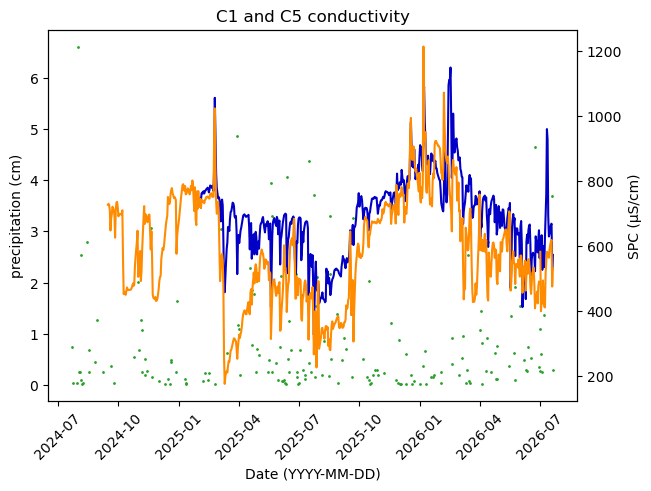

In [50]:
fig, ax1 = plt.subplots(layout='constrained')
ax1.set_xlabel('Date (YYYY-MM-DD)')
ax1.set_ylabel('precipitation (cm)')
rain = ax1.scatter(precip.Date, precip.PrecipitationCM, alpha = 1, color = "tab:green", s = 1, label = "precipitation (cm)")

ax1.tick_params(axis='x', rotation=45)
# ax1.set_ylim(0, 3)


ax2 = ax1.twinx() 
ax2.set_ylabel('SPC (µS/cm)') 
C1 = ax2.plot(C1hobodf.index, C1hobodf.loc[:, "Specific Conductivity"], color="#0200C6", label = "C1 daily average SPC")
C5 = ax2.plot(C5hobodf.index, C5hobodf.loc[:, "Specific Conductivity"], color="#FF8B00", label = "C5 daily average SPC")
# ax2.set_ylim(0, 1200)

plt.xticks(rotation=45)
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
plt.title("C1 and C5 conductivity")
# leg = rain + C5 + C1
# labs = [l.get_label() for l in leg]
# ax1.legend(leg, labs)

# plt.xlim(pd.to_datetime("2025-04"), pd.to_datetime("2025-05"))

plt.show();

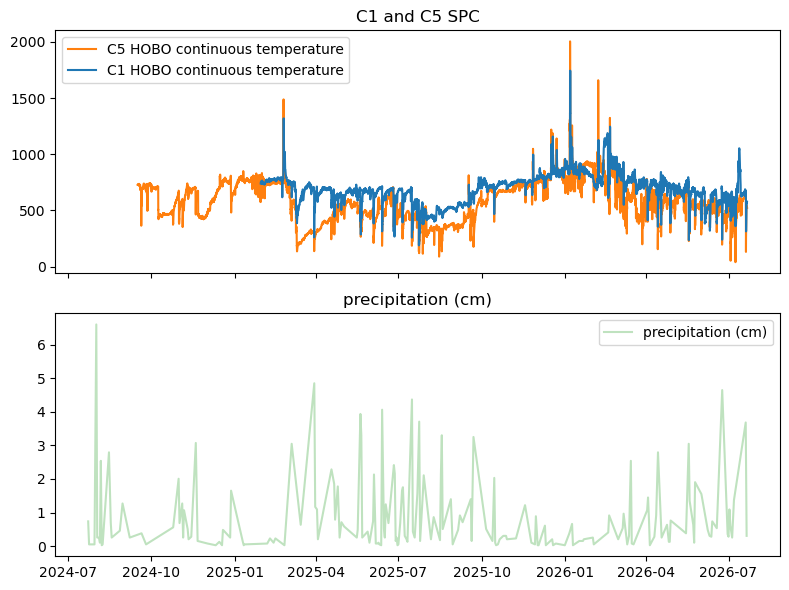

In [51]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True)

axs[0].plot(C5slicedhobodate, C5filteredhobo, color="tab:orange", label = "C5 HOBO continuous temperature")
axs[0].plot(C1slicedhobodate, C1filteredhobo, color="tab:blue", label = "C1 HOBO continuous temperature")
axs[0].set_title('C1 and C5 SPC')
axs[0].legend()

axs[1].plot(precip.Date, precip.PrecipitationCM, alpha = 0.3, color = "tab:green", label = "precipitation (cm)")
axs[1].set_title('precipitation (cm)')
axs[1].legend()

plt.tight_layout()
plt.show()
#google AI overview taught me this one 

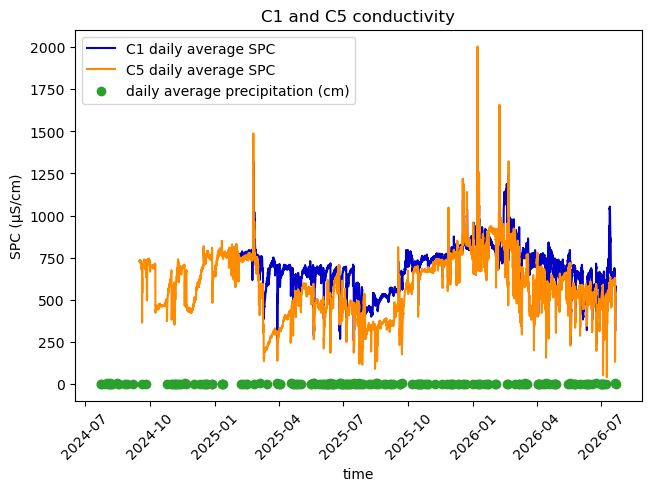

In [52]:
#this is just to make a legend that works
fig, ax = plt.subplots(layout='constrained')
ax.set_xlabel('time')
ax.set_ylabel('SPC (µS/cm)')
ax.plot(C1slicedhobodate, C1filteredhobo, color="#0200C6", label = "C1 daily average SPC")
ax.plot(C5slicedhobodate, C5filteredhobo, color="#FF8B00", label = "C5 daily average SPC")
ax.tick_params(axis='x', rotation=45)

ax.scatter(precip.Date, precip.PrecipitationCM, alpha = 1, color = "tab:green", label = "daily average precipitation (cm)")
# ax2.plot((precip.Date, precip.PrecipitationCM))
# ax2.tick_params(axis='y', labelcolor=color)
# ax.twinx.plot(precip.Date, precip.PrecipitationCM, color = "bisque", alpha = 0.5, label = "precipitation (cm)")

plt.xticks(rotation=45)
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
plt.title("C1 and C5 conductivity")

plt.legend()
# plt.xlim(pd.to_datetime("2025-04-01"), pd.to_datetime("2025-04-03"))

plt.show();

In [ ]:
# all these data sets probably need to be resampled for daily average!!!

In [68]:
#reading C3 continuous data
C3hobodf = pd.read_csv("Mdstrm_current.csv") 
C3hobodf["Date-Time"] = pd.to_datetime(C3hobodf["Date-Time"]) 
C3hobodf.index = pd.DatetimeIndex(C3hobodf["Date-Time"])

In [69]:
#filtering the C3 data for the outlier spikes where the hobo probe was removed from the piezometer
C3filtered = hampel(C3hobodf["Temperature"], window_size=6, n_sigma=1.5)

In [70]:
C3filtered = pd.DataFrame(C3filtered.filtered_data.to_numpy(), index=C3hobodf.index)

In [71]:
C3filteredSPC = hampel(C3hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)
C3filteredSPC = pd.DataFrame(C3filteredSPC.filtered_data.to_numpy(), index=C3hobodf.index)

In [72]:
C3hobodf["FilteredTemp"] = C3filtered
C3hobodf["FilteredSPC"] = C3filteredSPC

In [102]:
#reading C5 continuous data
C5hobodf = pd.read_csv("P5_creek_cond_current.csv") 
C5hobodf["Date-Time"] = pd.to_datetime(C5hobodf["Date-Time"]) 
C5hobodf.index = pd.DatetimeIndex(C5hobodf["Date-Time"])

In [103]:
#filtering the C5 data for the outlier spikes where the hobo probe was removed from the piezometer
C5filtered = hampel(C5hobodf["Temperature"], window_size=6, n_sigma=1.5)

In [104]:
C5filtered = pd.DataFrame(C5filtered.filtered_data.to_numpy(), index=C5hobodf.index)

In [105]:
C5filteredSPC = hampel(C5hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)
C5filteredSPC = pd.DataFrame(C5filteredSPC.filtered_data.to_numpy(), index=C5hobodf.index)

In [106]:
C5hobodf["FilteredTemp"] = C5filtered
C5hobodf["FilteredSPC"] = C5filteredSPC

In [107]:
#reading C5 continuous data
downst = pd.read_csv("Dwnstrm_current.csv") 
downst["Date-Time"] = pd.to_datetime(downst["Date-Time"]) 
downst.index = pd.DatetimeIndex(downst["Date-Time"])

In [108]:
#filtering the C5 data for the outlier spikes where the hobo probe was removed from the piezometer
downfilt = hampel(downst["Temperature"], window_size=6, n_sigma=1.5)

In [109]:
downfilt = pd.DataFrame(downfilt.filtered_data.to_numpy(), index=downst.index)

In [110]:
downstfiltSPC = hampel(downst["Specific Conductivity"], window_size=6, n_sigma=1.5)
downstfiltSPC = pd.DataFrame(downstfiltSPC.filtered_data.to_numpy(), index=downst.index)

In [111]:
downst["FilteredTemp"] = downfilt
downst["FilteredSPC"] = downstfiltSPC

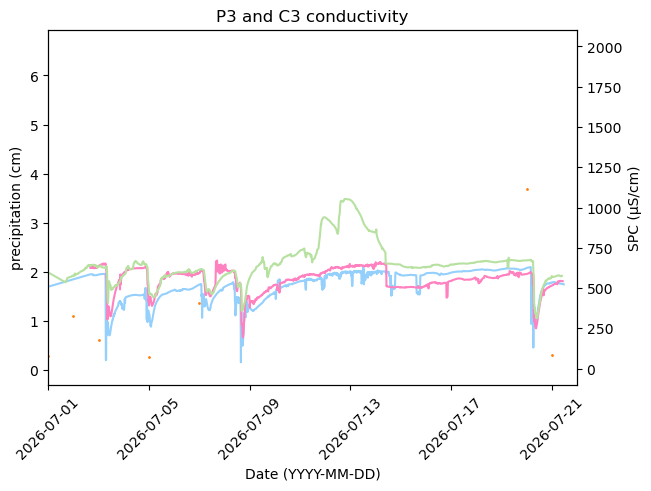

In [117]:
fig, ax1 = plt.subplots(layout='constrained')
ax1.set_xlabel('Date (YYYY-MM-DD)')
ax1.set_ylabel('precipitation (cm)')
rain = ax1.scatter(precip.Date, precip.PrecipitationCM, alpha = 1, s= 1, color = 'tab:orange', label = "precipitation (cm)")
# ax.scatter(weatherdf.Date, weatherdf.loc[:,"Mean  Celcius Teperature"], color = "green", s = 1, label = "air temperature")

ax1.tick_params(axis='x', rotation=45)
# ax1.set_ylim(0, 3)


ax2 = ax1.twinx() 
ax2.set_ylabel('SPC (µS/cm)') 
C5 = ax2.plot(C5hobodf.index, C5hobodf.FilteredSPC, color="xkcd:light blue", label = "C5 continuous SPC")
C3 = ax2.plot(C3hobodf.index, C3hobodf.FilteredSPC, color="xkcd:pink", label = "C3 continuous SPC")
down = ax2.plot(downst.index, downst.FilteredSPC,  color = "xkcd:light grey green", label = 'creek SPC at P3')
# ax2.set_ylim(0, 1200)
ax2.set_xlim((pd.to_datetime("2026-07-01"), pd.to_datetime("2026-07-22")))

plt.xticks(rotation=45)
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
plt.title("P3 and C3 conductivity")
# leg = rain + C3 + C1
# labs = [l.get_label() for l in leg]
# ax1.legend(leg, labs)

# plt.xlim(pd.to_datetime("2025-04"), pd.to_datetime("2025-05"))

plt.show();

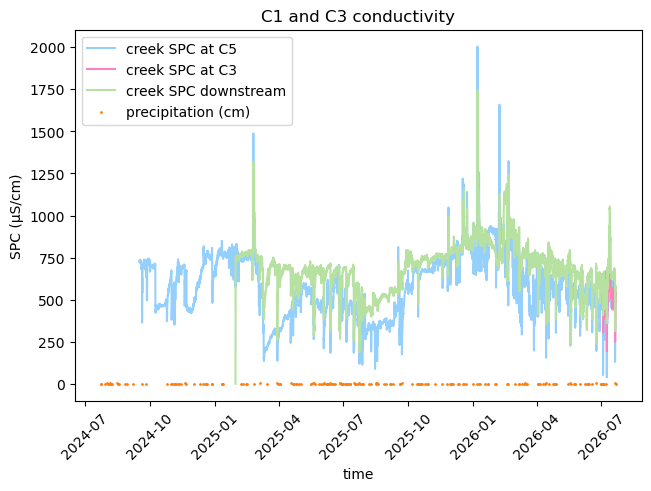

In [121]:
#this is just to make a legend that works
fig, ax = plt.subplots(layout='constrained')
ax.set_xlabel('time')
ax.set_ylabel('SPC (µS/cm)')
C5 = ax.plot(C5hobodf.index, C5hobodf.FilteredSPC, color="xkcd:light blue", label = 'creek SPC at C5')
C3 = ax.plot(C3hobodf.index, C3hobodf.FilteredSPC, color="xkcd:pink", label = 'creek SPC at C3')
down = ax.plot(downst.index, downst.FilteredSPC,  color = "xkcd:light grey green", label = 'creek SPC downstream')
ax.tick_params(axis='x', rotation=45)

rain = ax.scatter(precip.Date, precip.PrecipitationCM, alpha = 1, s= 1, color = 'tab:orange', label = "precipitation (cm)")
# ax2.plot((precip.Date, precip.PrecipitationCM))
# ax2.tick_params(axis='y', labelcolor=color)
# ax.twinx.plot(precip.Date, precip.PrecipitationCM, color = "bisque", alpha = 0.5, label = "precipitation (cm)")

plt.xticks(rotation=45)
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
plt.title("C1 and C3 conductivity")

plt.legend()
# plt.xlim(pd.to_datetime("2025-04-01"), pd.to_datetime("2025-04-03"))

plt.show();